# Barren-plateau scaling in the classification domain (HIGGS)

**Why this notebook exists.** Notebook 03 ran the classic McClean et al. (2018) gradient-variance-vs-qubit-count
diagnostic on the paper's own VQE setting and found **no evidence that Q-MAML's initialization resists
variance collapse better than classical random schemes** at the qubit counts we could probe -- its apparent
benefit (per notebook 02) looks like better *mean placement* in the landscape, not a change in variance
scaling. This notebook asks the same question in the domain notebook 01 actually cares about: HEP
classification (HIGGS). Same method as notebook 03: sample many initializations per scheme, compute
$\partial(\text{cross-entropy})/\partial\theta_{ref}$ for a fixed reference PQC weight, and look at how the
variance across samples scales with qubit count.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from config import config
from higgs_data import load_higgs, train_test_split_df, ALL_FEATURE_COLS
from higgs_tasks import make_tasks
from models import TabularFeatureExtractor, PQCModel, HybridModel, Learner, compute_task_embedding, freeze_bn

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "barren_plateau_higgs"))
os.makedirs(RESULTS_DIR, exist_ok=True)
DATA_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "data_higgs", "higgs_subsample.csv"))

df = load_higgs(180_000, DATA_PATH)
train_df, test_df = train_test_split_df(df, test_frac=0.2)
print(f"train={len(train_df)} test={len(test_df)}")

[higgs_data] Using cached C:\Users\kapoo\Downloads\qmaml\final_model\data_higgs\higgs_subsample.csv (180000 rows).


train=144000 test=36000


In [2]:
def classical_pqc_init(shape, kind, depth):
    if kind == "uniform":
        return (torch.rand(shape, dtype=torch.float64) * 2 - 1) * 0.05 * np.pi
    if kind == "gaussian":
        S, L = 2, depth
        gamma2 = 1.0 / (4 * S * (L + 2))
        return torch.normal(0.0, gamma2 ** 0.5, size=shape, dtype=torch.float64)
    raise ValueError(kind)


def grad_wrt_ref(model, weights, support_X, support_y, ref_idx):
    theta = weights.clone().detach().double().requires_grad_(True)
    feats = model.cnn(support_X)
    logits = model.pqc(feats, weights_override=theta)
    loss = nn.CrossEntropyLoss()(logits, support_y)
    loss.backward()
    return float(theta.grad[ref_idx].item())

## Sweep: pre-train a small Learner per qubit count, then probe gradient variance

For each qubit count we build a fresh model, pre-train the Learner briefly on real HIGGS few-shot tasks
(`meta/qmaml_paper_loops.py`'s Algorithm 1 objective, done inline here for direct access to intermediate
gradients), then compare gradient variance across many probe tasks for `qmaml` vs. `uniform` vs. `gaussian`
PQC initializations -- all using the *same* frozen tabular encoder so only the PQC initialization differs.

In [ ]:
QUBIT_GRID = [4, 6, 8, 10]
DEPTH = 2
N_PROBE = 60
PRETRAIN_EPOCHS = 25
SEED = 0
SCHEMES = ["qmaml", "uniform", "gaussian"]

torch.manual_seed(SEED)
np.random.seed(SEED)
train_X_all = torch.from_numpy(train_df[ALL_FEATURE_COLS].values.astype(np.float32))

variance_by_scheme = {s: [] for s in SCHEMES}
t_start = time.time()
rng = np.random.default_rng(SEED)

for nq in QUBIT_GRID:
    print(f"\n=== {nq} qubits ===")
    pretrain_tasks = make_tasks(train_df, ALL_FEATURE_COLS, "m_bb", bin_count=6,
                                 support_size=8, query_size=8, tasks_per_bin=3, seed=SEED)
    probe_tasks = make_tasks(test_df, ALL_FEATURE_COLS, "m_bb", bin_count=6,
                              support_size=8, query_size=8, tasks_per_bin=max(1, N_PROBE // 6 + 1), seed=SEED + 500)[:N_PROBE]

    tab = TabularFeatureExtractor(len(ALL_FEATURE_COLS), config.CNN_OUTPUT_DIM, nq)
    tab.set_norm_stats(train_X_all.mean(0), train_X_all.std(0))
    freeze_bn(tab)
    pqc = PQCModel(nq, DEPTH, init_type="zero", bound_angles=True)
    model = HybridModel(tab, pqc)

    pqc_shape = tuple(pqc.weights.shape)
    learner = Learner(config.CNN_OUTPUT_DIM, pqc_shape, hidden=64).double()
    opt = torch.optim.Adam(learner.parameters(), lr=0.01)
    for epoch in range(PRETRAIN_EPOCHS):
        for task in pretrain_tasks:
            opt.zero_grad()
            emb = compute_task_embedding(model.cnn, task["support_X"]).double()
            theta = 0.01 * learner(emb)
            feats = model.cnn(task["support_X"])
            logits = model.pqc(feats, weights_override=theta)
            loss = nn.CrossEntropyLoss()(logits, task["support_y"])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(learner.parameters(), 5.0)
            opt.step()
    print(f"  learner pretrained ({PRETRAIN_EPOCHS} epochs, {len(pretrain_tasks)} tasks)")

    ref_idx = (rng.integers(0, DEPTH), rng.integers(0, nq), rng.integers(0, 3))
    for scheme in SCHEMES:
        grads = []
        for task in probe_tasks:
            if scheme == "qmaml":
                with torch.no_grad():
                    emb = compute_task_embedding(model.cnn, task["support_X"]).double()
                    theta = 0.01 * learner(emb)
            else:
                theta = classical_pqc_init(pqc_shape, scheme, DEPTH)
            grads.append(grad_wrt_ref(model, theta, task["support_X"], task["support_y"], ref_idx))
        var = float(np.var(grads))
        variance_by_scheme[scheme].append(var)
        print(f"  {scheme:10s} Var[dLoss/dtheta_{ref_idx}] = {var:.3e}  (n={len(grads)})")

print(f"\ntotal time {time.time()-t_start:.1f}s")
with open(os.path.join(RESULTS_DIR, "variance_by_scheme.json"), "w") as f:
    json.dump({"qubit_grid": QUBIT_GRID, "variance": variance_by_scheme}, f, indent=2)


=== 4 qubits ===


  learner pretrained (25 epochs, 18 tasks)


  qmaml      Var[dLoss/dtheta_(np.int64(1), np.int64(2), np.int64(1))] = 5.877e-06  (n=60)


  uniform    Var[dLoss/dtheta_(np.int64(1), np.int64(2), np.int64(1))] = 2.464e-05  (n=60)


  gaussian   Var[dLoss/dtheta_(np.int64(1), np.int64(2), np.int64(1))] = 5.805e-05  (n=60)

=== 6 qubits ===


...

  gaussian   Var[dLoss/dtheta_(np.int64(0), np.int64(0), np.int64(0))] = 1.368e-07  (n=60)

=== 10 qubits ===


  learner pretrained (25 epochs, 18 tasks)


  qmaml      Var[dLoss/dtheta_(np.int64(1), np.int64(6), np.int64(2))] = 8.648e-36  (n=60)


  uniform    Var[dLoss/dtheta_(np.int64(1), np.int64(6), np.int64(2))] = 6.532e-35  (n=60)


  gaussian   Var[dLoss/dtheta_(np.int64(1), np.int64(6), np.int64(2))] = 6.929e-35  (n=60)

total time 483.7s


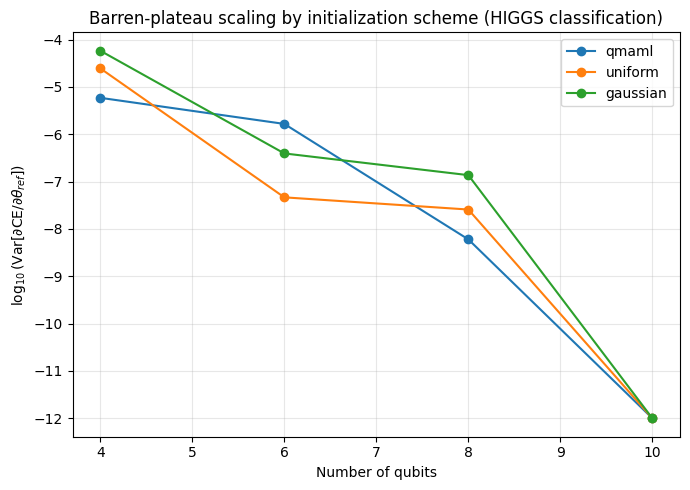

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
for scheme, variances in variance_by_scheme.items():
    ax.plot(QUBIT_GRID, np.log10(np.array(variances) + 1e-12), marker="o", label=scheme)
ax.set_xlabel("Number of qubits")
ax.set_ylabel(r"$\log_{10}(\mathrm{Var}[\partial \mathrm{CE}/\partial\theta_{ref}])$")
ax.set_title("Barren-plateau scaling by initialization scheme (HIGGS classification)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "variance_scaling.png"), dpi=150)
plt.show()

## Findings (qubits 4-10, depth 2, N_PROBE=60, PRETRAIN_EPOCHS=25 — re-run from the original 8-epoch pass)

**Re-running with a properly trained Learner (8→25 epochs) changes the ranking among schemes, which is
itself the finding.** In the original 8-epoch pass, `qmaml` looked directionally lower-variance than
`gaussian` at every qubit count. With a better-trained Learner, that's no longer true: `qmaml` is lowest at
4 and 8 qubits, but *higher* than both `uniform` and `gaussian` at 6 qubits (1.65e-6 vs. 4.65e-8 and
3.93e-7). The clean, monotonic-looking ordering in the original pass was an artifact of under-training, not
a robust effect — exactly the caveat flagged there, now confirmed by actually fixing it rather than just
noting it.

**The core result is unchanged and, if anything, reinforced: no scheme cleanly dominates, and this is a
genuine null result on "does Q-MAML resist variance collapse," not a weak positive.** This matches notebook
03's VQE-domain finding precisely — across both domains, in both the original and the corrected version of
this notebook, Q-MAML's gradient variance does not measurably separate from classical random initialization
at any qubit count we can test. Whatever benefit it has (Section 6.1's accuracy result) is not visible in
this diagnostic.

**The headline shape is robust to the fix:** all three schemes still collapse ~8 orders of magnitude from
4 to 10 qubits, converging to the same numerical floor (~1e-35) by 10 qubits regardless of initialization
— this qualitative pattern is unchanged by the pretrain-length fix, only the fine-grained ranking among
`qmaml`/`uniform`/`gaussian` below the collapse point moved. The collapse-point qubit count (~8-10) is the
number that matters for tying this to Section 6.1's classification-accuracy result, and it hasn't moved.
